1. Normal vs Anomaly counts:
IsAnomaly
0    995000
1      5000
Name: count, dtype: int64


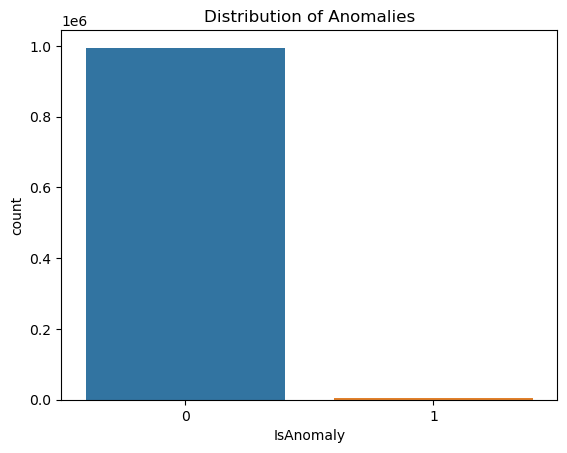

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("network_traffic.csv")

df['PacketCount'] = df['PacketsSent'] + df['PacketsReceived']

print("1. Normal vs Anomaly counts:")
print(df['IsAnomaly'].value_counts())
sns.countplot(data=df, x='IsAnomaly')
plt.title("Distribution of Anomalies")
plt.show()


In [2]:

print("\n2. Protocol distribution in anomalies:")
print(df[df['IsAnomaly'] == 1]['Protocol'].value_counts())



2. Protocol distribution in anomalies:
Protocol
 0.742095    1
-0.796308    1
 0.624279    1
 2.775919    1
 0.151820    1
            ..
-0.936590    1
 1.239821    1
 1.412512    1
 0.354785    1
 1.698639    1
Name: count, Length: 5000, dtype: int64


In [3]:
print("\n3. Top 5 Source IPs causing anomalies:")
print(df[df['IsAnomaly'] == 1]['SourceIP'].value_counts().head())


3. Top 5 Source IPs causing anomalies:
SourceIP
 0.677926    1
-0.865737    1
 1.106280    1
-0.540288    1
-1.765846    1
Name: count, dtype: int64


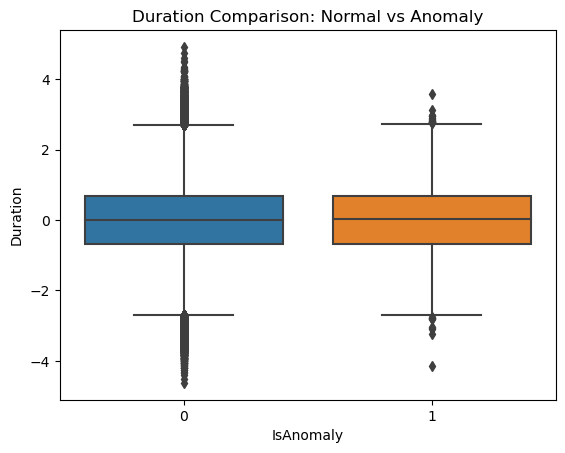

In [4]:
sns.boxplot(data=df, x='IsAnomaly', y='Duration')
plt.title("Duration Comparison: Normal vs Anomaly")
plt.show()

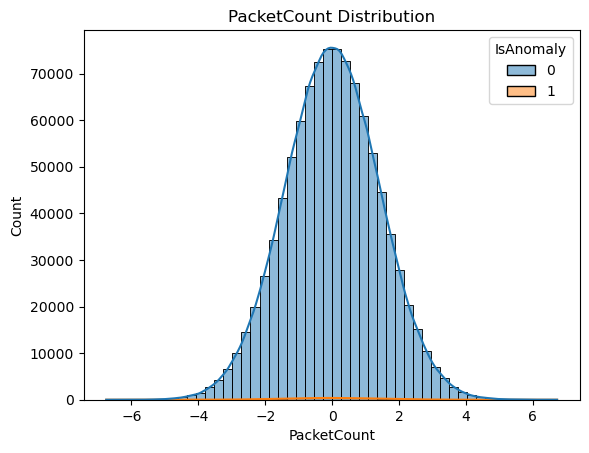

In [6]:
sns.histplot(data=df, x='PacketCount', hue='IsAnomaly', bins=50, kde=True)
plt.title("PacketCount Distribution")
plt.show()

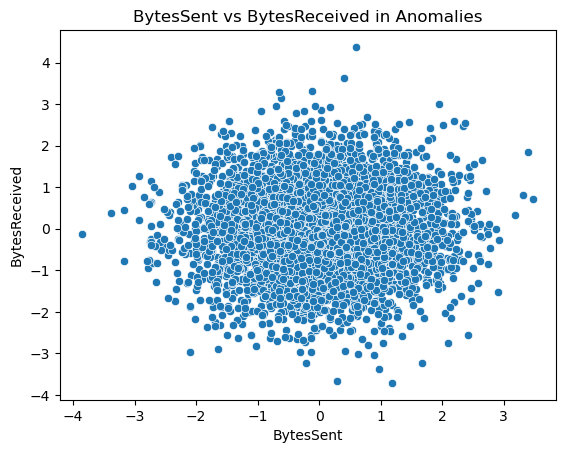

In [8]:
anomaly_df = df[df['IsAnomaly'] == 1]
sns.scatterplot(data=anomaly_df, x='BytesSent', y='BytesReceived')
plt.title("BytesSent vs BytesReceived in Anomalies")
plt.show()

In [29]:
df['PortPair'] = df['SourcePort'].astype(str) + "-" + df['DestinationPort'].astype(str)
print("\n8. Top 5 Port pairs in anomalies:")
print(df[df['IsAnomaly'] == 1]['PortPair'].value_counts().head())



8. Top 5 Port pairs in anomalies:
PortPair
0.5972334781834925--0.3268265915244439     1
-0.6338900811744935--0.4677461800245633    1
1.237429426080421--0.4134870969152516      1
0.0437918123641982-1.5364532527667905      1
0.6630242894431367--0.6962694335943497     1
Name: count, dtype: int64



9. Top 5 Destination IPs in anomalies:
DestinationIP
-0.487911    1
-0.034869    1
 1.774853    1
 0.611391    1
 0.113843    1
Name: count, dtype: int64

10. Traffic Direction Patterns:


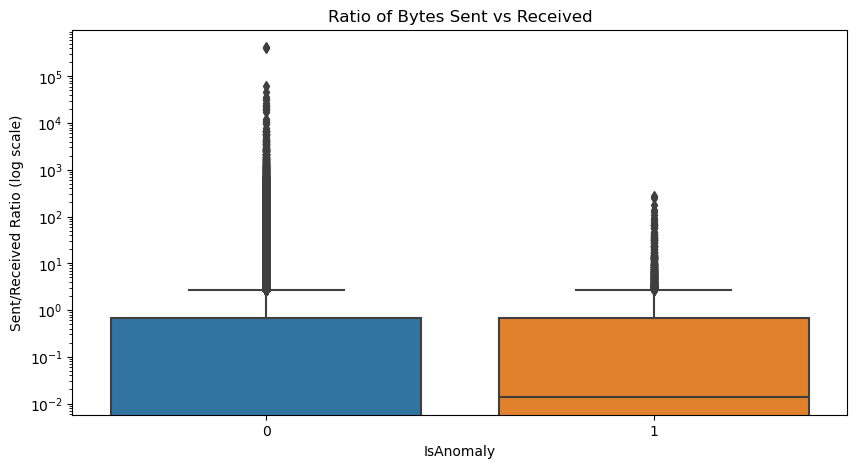

In [11]:
print("\n9. Top 5 Destination IPs in anomalies:")
print(df[df['IsAnomaly'] == 1]['DestinationIP'].value_counts().head())

print("\n10. Traffic Direction Patterns:")
df['TrafficRatio'] = df['BytesSent'] / (df['BytesReceived'] + 1)  

plt.figure(figsize=(10,5))
sns.boxplot(x='IsAnomaly', y='TrafficRatio', data=df)
plt.yscale('log')  
plt.title("Ratio of Bytes Sent vs Received")
plt.ylabel("Sent/Received Ratio (log scale)")
plt.show()



11. Common Port Pairs in Anomalies:


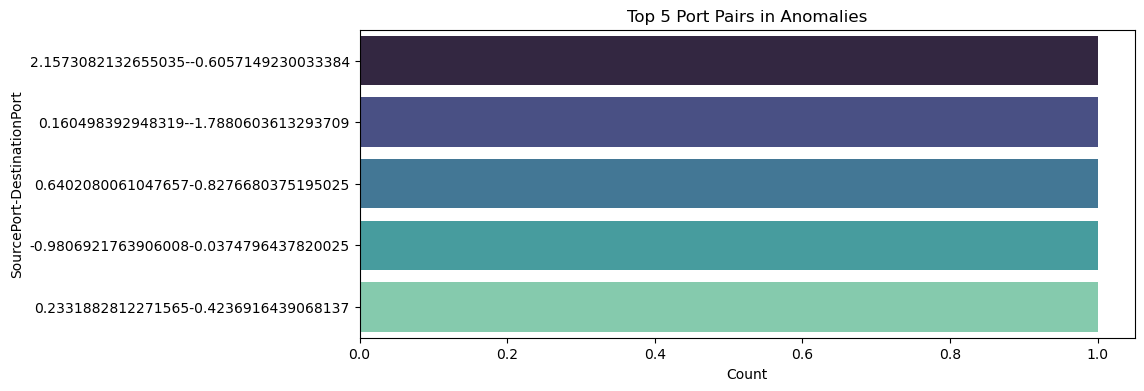

In [12]:
print("\n11. Common Port Pairs in Anomalies:")
df['PortPair'] = df['SourcePort'].astype(str) + "-" + df['DestinationPort'].astype(str)
top_port_pairs = df[df['IsAnomaly']==1]['PortPair'].value_counts().nlargest(5)

plt.figure(figsize=(10,4))
sns.barplot(x=top_port_pairs.values, y=top_port_pairs.index, palette="mako")
plt.title("Top 5 Port Pairs in Anomalies")
plt.xlabel("Count")
plt.ylabel("SourcePort-DestinationPort")
plt.show()



12. Protocol-Specific Anomaly Patterns:


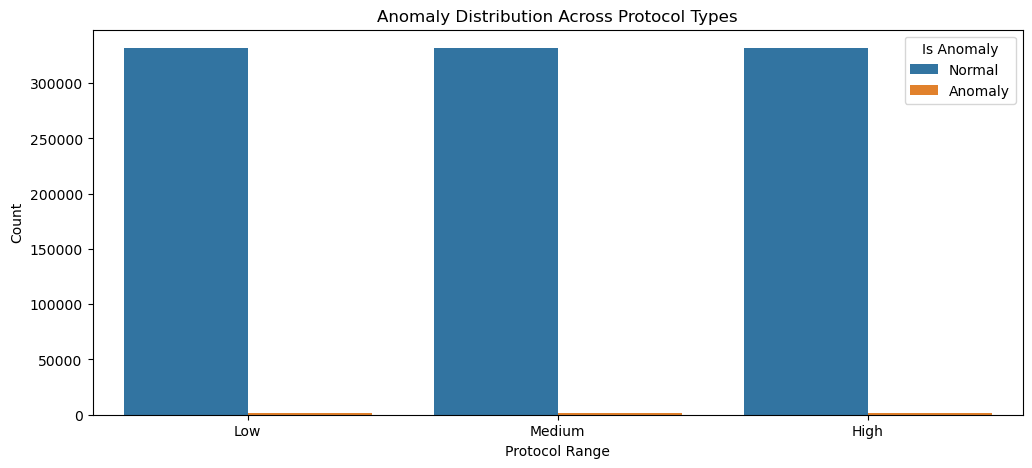

In [13]:
print("\n12. Protocol-Specific Anomaly Patterns:")

df['ProtocolType'] = pd.qcut(df['Protocol'], q=3, labels=['Low','Medium','High'])

plt.figure(figsize=(12,5))
sns.countplot(data=df, x='ProtocolType', hue='IsAnomaly')
plt.title("Anomaly Distribution Across Protocol Types")
plt.xlabel("Protocol Range")
plt.ylabel("Count")
plt.legend(title='Is Anomaly', labels=['Normal', 'Anomaly'])
plt.show()


13. Traffic Concentration by IP:


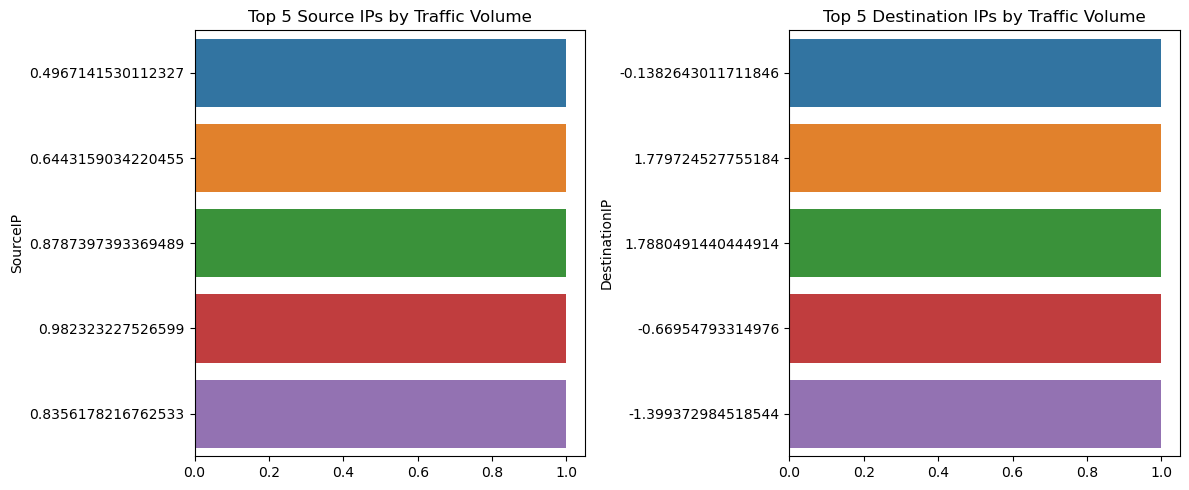

In [14]:
print("\n13. Traffic Concentration by IP:")
top_sources = df['SourceIP'].value_counts().nlargest(5)
top_dests = df['DestinationIP'].value_counts().nlargest(5)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.barplot(x=top_sources.values, y=top_sources.index.astype(str))
plt.title("Top 5 Source IPs by Traffic Volume")

plt.subplot(1,2,2)
sns.barplot(x=top_dests.values, y=top_dests.index.astype(str))
plt.title("Top 5 Destination IPs by Traffic Volume")
plt.tight_layout()
plt.show()


14. Packet Size Distribution:


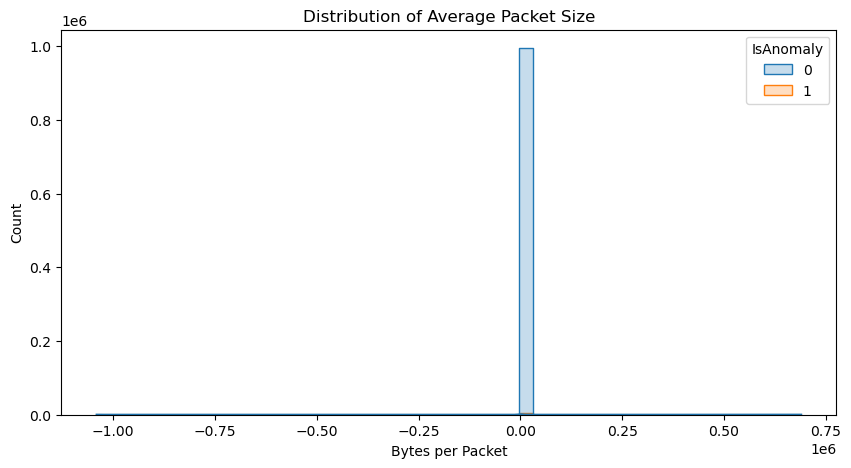

In [15]:
print("\n14. Packet Size Distribution:")
df['AvgPacketSize'] = (df['BytesSent'] + df['BytesReceived']) / \
                     (df['PacketsSent'] + df['PacketsReceived'] + 1)

plt.figure(figsize=(10,5))
sns.histplot(data=df, x='AvgPacketSize', hue='IsAnomaly', 
             bins=50, kde=True, element='step')
plt.title("Distribution of Average Packet Size")
plt.xlabel("Bytes per Packet")
plt.show()



15. Duration vs Packet Count Relationship:


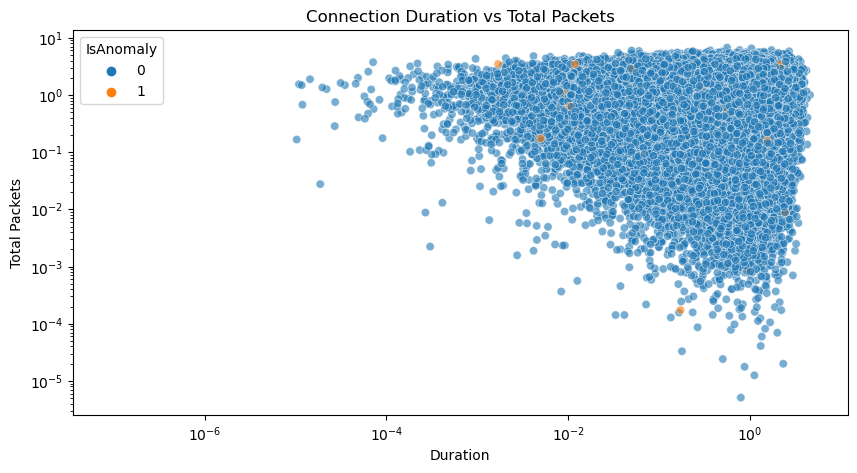

In [16]:
print("\n15. Duration vs Packet Count Relationship:")
df['TotalPackets'] = df['PacketsSent'] + df['PacketsReceived']

plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='Duration', y='TotalPackets', 
                hue='IsAnomaly', alpha=0.6)
plt.title("Connection Duration vs Total Packets")
plt.ylabel("Total Packets")
plt.xscale('log')
plt.yscale('log')
plt.show()


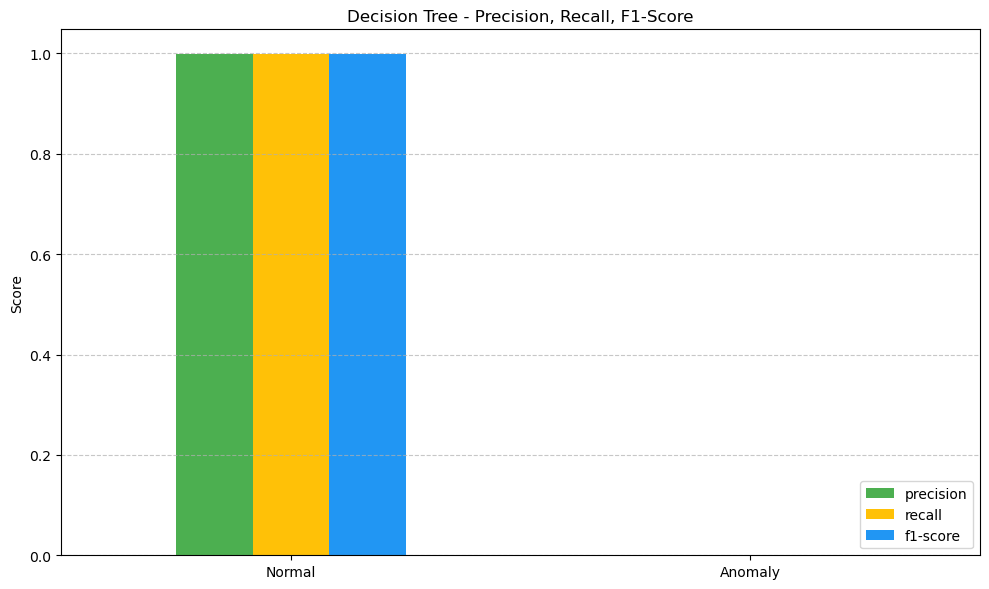

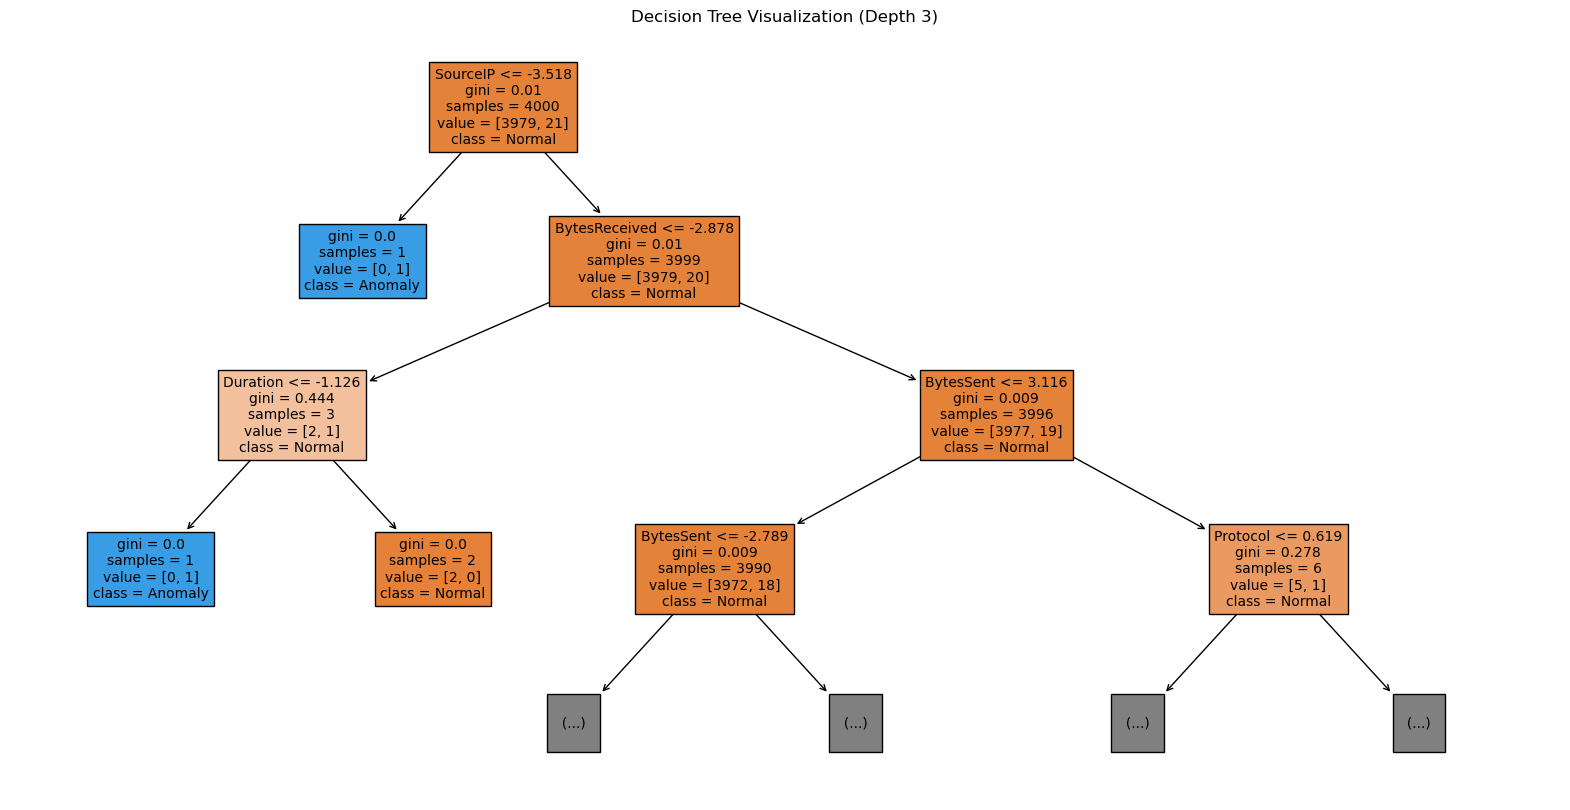

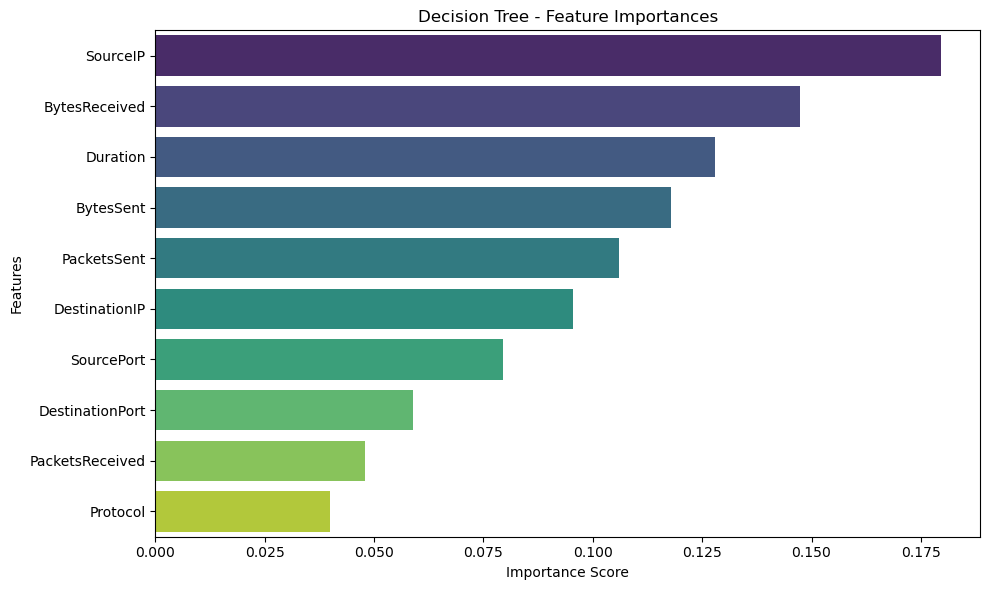

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


df = pd.read_csv("network_traffic.csv").sample(n=5000, random_state=42)
X = df.drop("IsAnomaly", axis=1)
y = df["IsAnomaly"]
X_scaled = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(10, 6))
report_df.loc[['0', '1'], ['precision', 'recall', 'f1-score']].plot(
    kind='bar', ax=plt.gca(), color=['#4CAF50', '#FFC107', '#2196F3']
)
plt.title("Decision Tree - Precision, Recall, F1-Score")
plt.ylabel("Score")
plt.xticks(ticks=[0, 1], labels=['Normal', 'Anomaly'], rotation=0)

plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 10))
plot_tree(
    model,
    filled=True,
    feature_names=X.columns.tolist(),  # <-- Fix applied here
    class_names=['Normal', 'Anomaly'],
    max_depth=3,
    fontsize=10
)

plt.title("Decision Tree Visualization (Depth 3)")
plt.show()

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns[indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=features, palette="viridis")
plt.title("Decision Tree - Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()



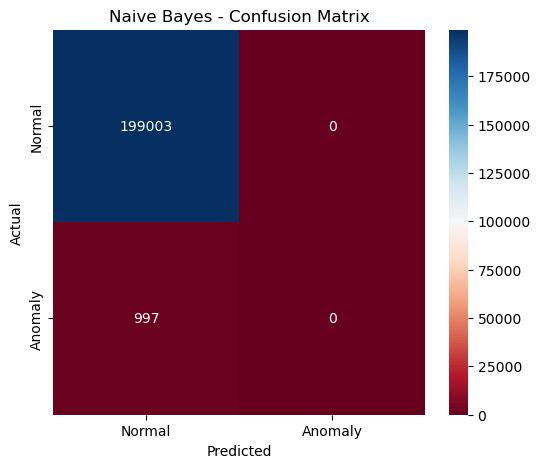

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Naive Bayes - Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    199003
           1       0.00      0.00      0.00       997

    accuracy                           1.00    200000
   macro avg       0.50      0.50      0.50    200000
weighted avg       0.99      1.00      0.99    200000



In [26]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="RdBu", xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Naive Bayes - Classification Report:\n", classification_report(y_test, y_pred))



Confusion Matrix:
 [[199003      0]
 [   997      0]]


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    199003
           1       0.00      0.00      0.00       997

    accuracy                           1.00    200000
   macro avg       0.50      0.50      0.50    200000
weighted avg       0.99      1.00      0.99    200000



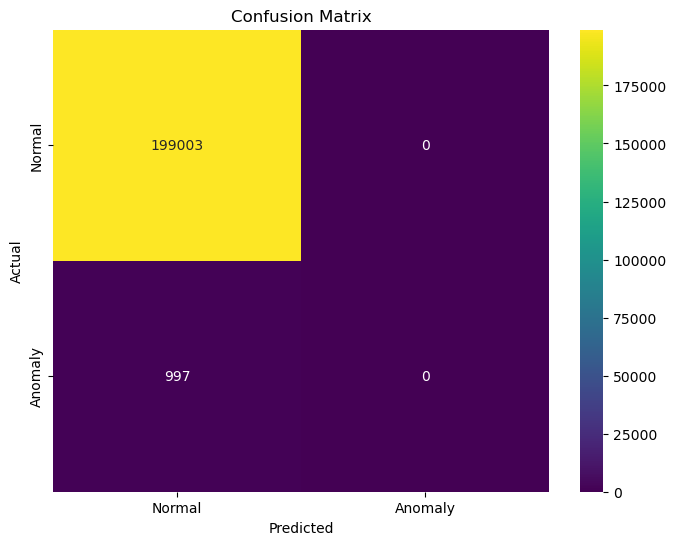

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("network_traffic.csv")

X = df.drop("IsAnomaly", axis=1)
y = df["IsAnomaly"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='viridis', xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()




C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


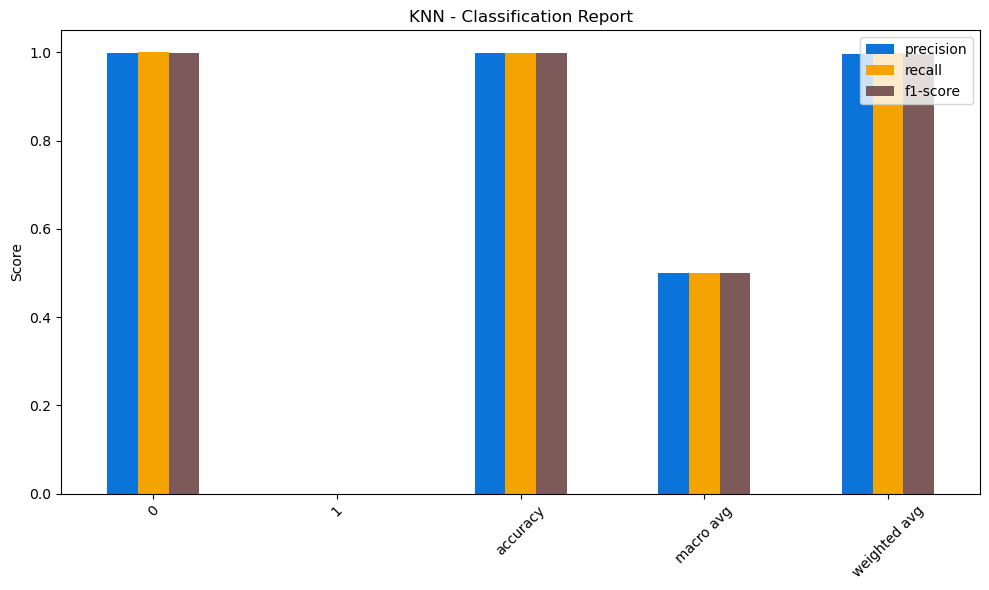

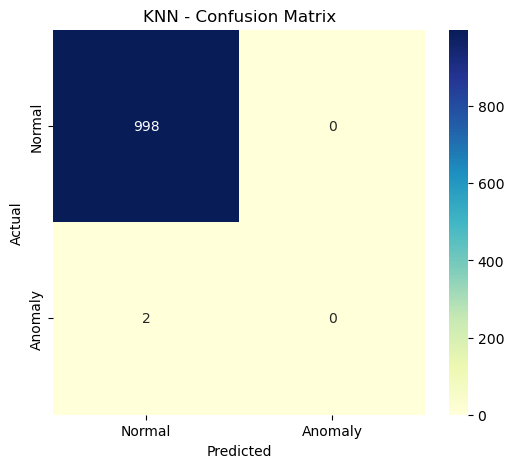

KNN - Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       998
           1       0.00      0.00      0.00         2

    accuracy                           1.00      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       1.00      1.00      1.00      1000



C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [28]:

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


df = pd.read_csv("network_traffic.csv").sample(n=5000, random_state=42)
X = df.drop("IsAnomaly", axis=1)
y = df["IsAnomaly"]
X = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(10, 6))
report_df[['precision', 'recall', 'f1-score']].plot(kind='bar', color=['#0A74DA', '#F4A300', '#7D5A5A'], ax=plt.gca())
plt.title("KNN - Classification Report")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='YlGnBu', xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("KNN - Classification Report:\n", classification_report(y_test, y_pred))

